In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d datamunge/sign-language-mnist

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 149MB/s]



In [ ]:
!unzip -q sign-language-mnist.zip

**Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

In [ ]:
train_df=pd.read_csv('sign_mnist_train.csv')
test_df=pd.read_csv('sign_mnist_test.csv')

In [ ]:
X_train = train_df.drop('label',axis=1).values
y_train = train_df['label'].values

In [ ]:
X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [ ]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [ ]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

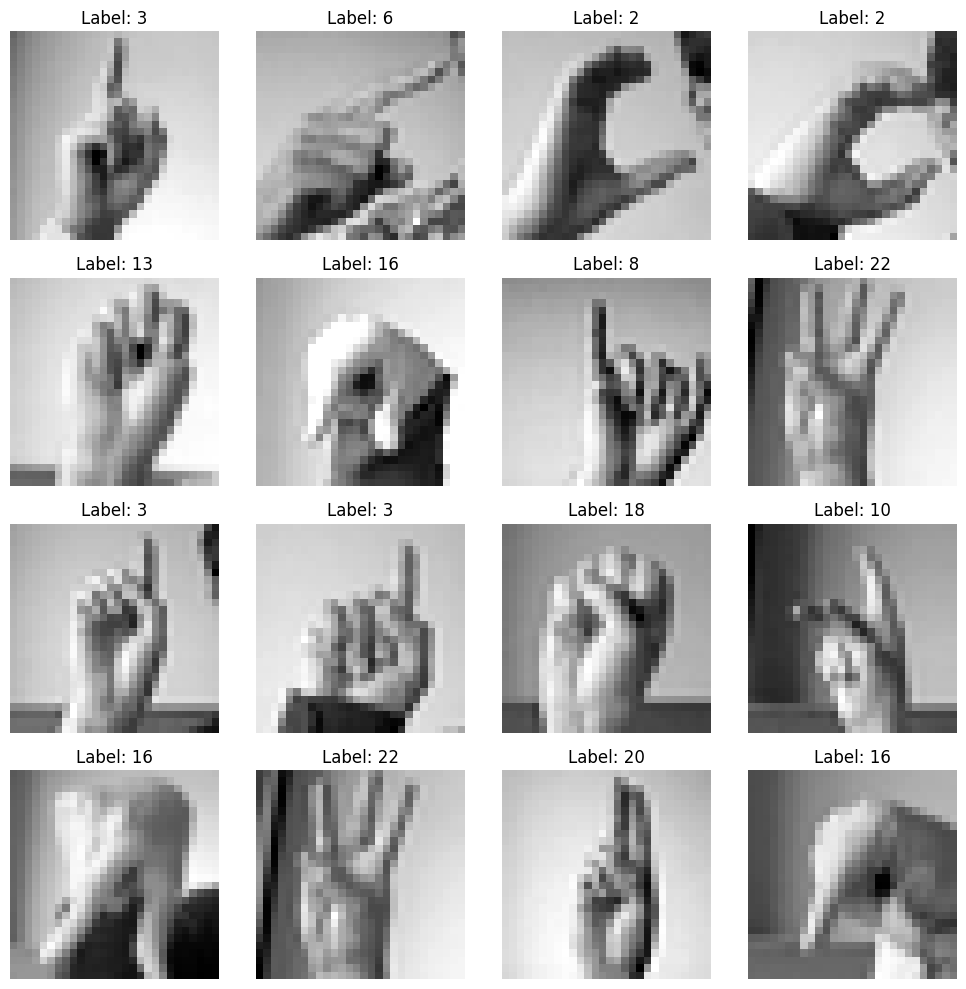

In [ ]:
plt.figure(figsize=(10,10))
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(X_train[i].squeeze(),cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")
plt.tight_layout()
plt.show()

**index to alphabet**

In [ ]:
unique_labels=sorted(np.unique(y_train))

label_to_index={
    label:index
    for index,label in enumerate(unique_labels)
}

index_to_label = {
    index:label
    for label,index in label_to_index.items()
}

In [ ]:
y_train_encoded = np.array([label_to_index[label] for label in y_train])
y_test_encoded = np.array([label_to_index[label] for label in y_test])

In [ ]:
letters = [
    'A','B','C','D','E','F','G','H',
    'I','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y'
]

**train_test_split**

In [ ]:
X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded
)

**Model**

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',padding='valid',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3),activation='relu',padding='valid'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(24,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Training**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val,y_val)
)

Epoch 1/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5948 - loss: 1.3866 - val_accuracy: 0.8722 - val_loss: 0.3970
Epoch 2/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9557 - loss: 0.1768 - val_accuracy: 0.9949 - val_loss: 0.0536
Epoch 3/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9974 - loss: 0.0317 - val_accuracy: 0.9942 - val_loss: 0.0327
Epoch 4/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9996 - loss: 0.0100 - val_accuracy: 0.9996 - val_loss: 0.0079
Epoch 5/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 6/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9929 - loss: 0.0261 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 8/10
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 9.5726e-04 - val_accurac

**Plotting**

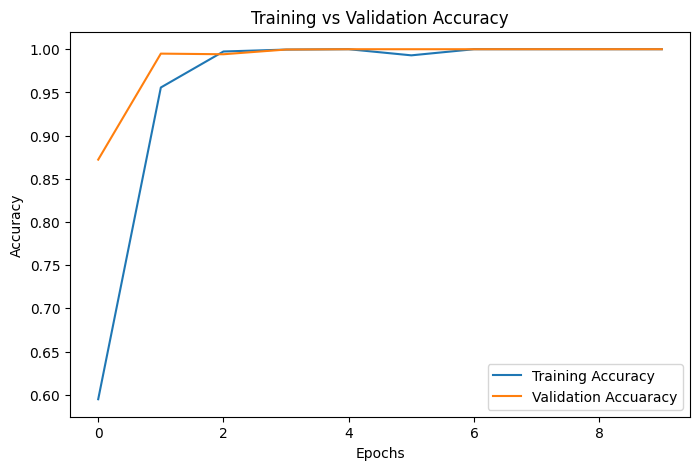

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuaracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

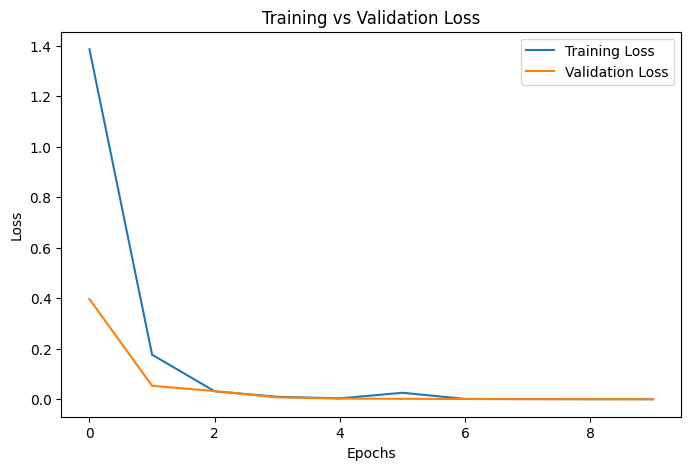

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

**Predictions**

In [ ]:
predictions=model.predict(X_test)
predicted_classes=np.argmax(predictions,axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print(classification_report(
    y_test_encoded,
    predicted_classes,
    target_names=letters
  )
)

              precision    recall  f1-score   support

           A       0.89      1.00      0.94       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      0.92      0.96       245
           E       0.84      0.92      0.88       498
           F       0.95      1.00      0.97       247
           G       0.91      0.89      0.90       348
           H       0.88      0.89      0.89       436
           I       0.95      0.93      0.94       288
           K       0.91      0.84      0.87       331
           L       0.87      0.99      0.93       209
           M       1.00      0.79      0.88       394
           N       0.73      0.66      0.69       291
           O       1.00      0.78      0.87       246
           P       0.91      1.00      0.95       347
           Q       0.88      1.00      0.94       164
           R       0.70      0.85      0.77       144
           S       0.66    

**Testing** **a** **new** **image**

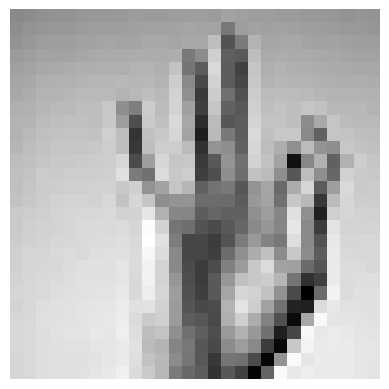

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Letter:  F
Actual Letter:  F


In [ ]:
index=1

image=X_test[index]

plt.imshow(image.squeeze(),cmap="gray")

plt.axis("off")
plt.show()

prediction=model.predict(
    np.expand_dims(image,axis=0)
)
predicted_index=np.argmax(prediction)

print("Predicted Letter: ",letters[predicted_index])
print("Actual Letter: ",letters[y_test_encoded[index]])

**Saving** **the** **model**

In [ ]:
model.save('sign_language_cnn.keras')

In [ ]:
from google.colab import files
files.download(
    'sign_language_cnn.keras'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>